In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("Analysis_ABC.csv")

In [24]:
# Remove commas and convert to number
df['Annual_Revenue'] = df['Annual_Revenue'].astype(str).str.replace(',', '').astype(float)

In [25]:
# Sort by revenue (highest first)
df = df.sort_values(by='Annual_Revenue', ascending=False).reset_index(drop=True)

In [26]:
# Total Revenue
total_revenue = df['Annual_Revenue'].sum()

In [27]:
# % of Total Revenue
df['% of Total Revenue'] = (df['Annual_Revenue'] / total_revenue * 100).round(2)

In [28]:
# Cumulative %
df['Cumulative %'] = df['% of Total Revenue'].cumsum().round(2)

In [29]:
# Assign A/B/C categories
def assign_category(cum_pct):
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'

df['Category'] = df['Cumulative %'].apply(assign_category)

In [30]:
print("\n" + "="*60)
print("ABC ANALYSIS COMPLETED!")
print("="*60)
print(df[['SKU', 'Items', 'Annual_Revenue', '% of Total Revenue', 'Cumulative %', 'Category']].to_string(index=False))

# Summary
print(f"\n📊 SUMMARY:")
print(f"A items : {len(df[df['Category']=='A'])} SKUs → {df[df['Category']=='A']['Cumulative %'].max():.2f}% of revenue")
print(f"B items : {len(df[df['Category']=='B'])} SKUs")
print(f"C items : {len(df[df['Category']=='C'])} SKUs")
print(f"Total Revenue : ₹{total_revenue:,.0f}")


✅ ABC ANALYSIS COMPLETED!
  SKU            Items  Annual_Revenue  % of Total Revenue  Cumulative % Category
SKU01  Beauty Products         20000.0               18.60         18.60        A
SKU09          Laundry         18000.0               16.74         35.34        A
SKU02    Personal Care         15000.0               13.95         49.29        A
SKU03        Home Care         12000.0               11.16         60.45        A
SKU07        Hair Care         12000.0               11.16         71.61        A
SKU06        Baby Care         10000.0                9.30         80.91        B
SKU04 Nutrition (Food)          8000.0                7.44         88.35        B
SKU08     Refreshments          7000.0                6.51         94.86        B
SKU05        Ice Cream          5000.0                4.65         99.51        C
SKU10        Packaging           500.0                0.47         99.98        C

📊 SUMMARY:
A items : 5 SKUs → 71.61% of revenue
B items : 3 SKUs
C ite

In [31]:
# Save results
df.to_csv('ABC_Analysis_Final.csv', index=False)
df.to_excel('ABC_Analysis_Final.xlsx', index=False)
print("\n💾 Saved: ABC_Analysis_Final.csv and ABC_Analysis_Final.xlsx")


💾 Saved: ABC_Analysis_Final.csv and ABC_Analysis_Final.xlsx


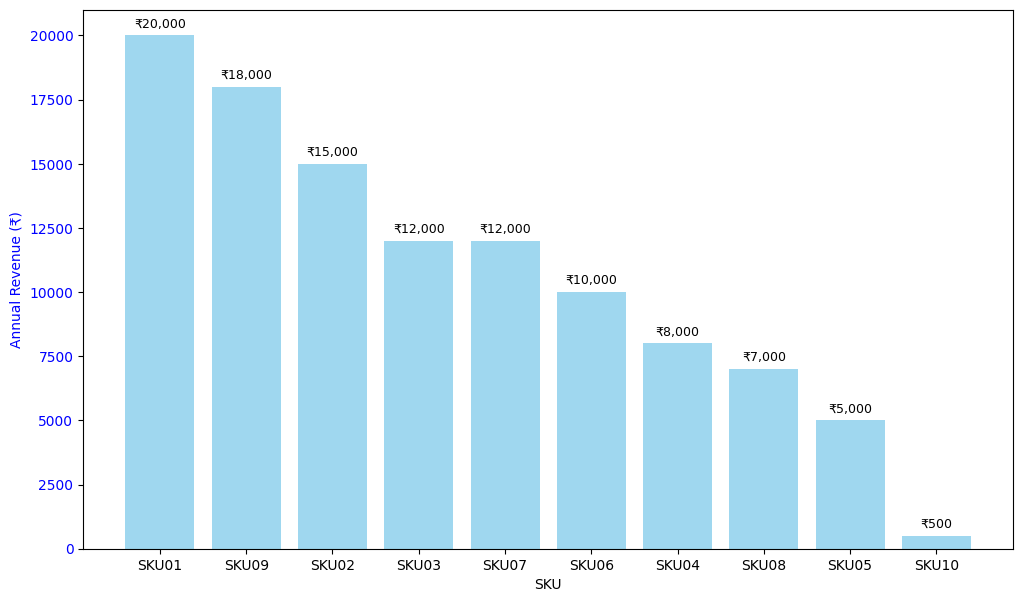

In [35]:
# ==================== 5. PARETO CHART (GRAPH) ====================
plt.figure(figsize=(12, 7))

# Bar chart for Annual Revenue
ax1 = plt.gca()
bars = ax1.bar(df['SKU'], df['Annual_Revenue'], color='skyblue', alpha=0.8)
ax1.set_ylabel('Annual Revenue (₹)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('SKU')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'₹{height:,.0f}', ha='center', va='bottom', fontsize=9)

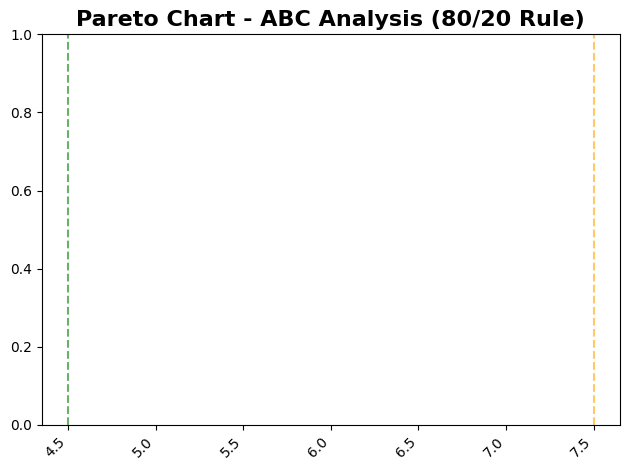

In [37]:
# Cumulative % line (on secondary axis)
ax2 = ax1.twinx()
line = ax2.plot(df['SKU'], df['Cumulative %'], color='red', marker='o', linewidth=2.5, markersize=6)
ax2.set_ylabel('Cumulative %', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

# Title and grid
plt.title('Pareto Chart - ABC Analysis (80/20 Rule)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add A/B/C zone labels
plt.axvline(x=4.5, color='green', linestyle='--', alpha=0.6)   # After A items (approx)
plt.axvline(x=7.5, color='orange', linestyle='--', alpha=0.6)  # After B items

plt.tight_layout()
plt.show()

# Optional: Save the graph as image
plt.savefig('Pareto_Chart_ABC_Analysis.png', dpi=300, bbox_inches='tight')
print("\n💾 Graph saved as: Pareto_Chart_ABC_Analysis.png")